In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/customer_churn.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
#Fix TotalCharges

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
#check changes

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
#Check missing values

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
#remove missing values

df = df.dropna()

In [10]:
#check changes

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [11]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

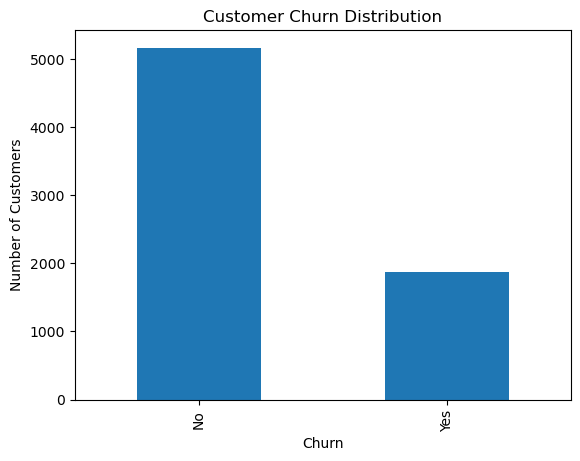

In [12]:
#Visualize churn distribution

import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure()
churn_counts.plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Approximately 26.6% of customers have churned, indicating a significant retention issue affecting more than one in four customers.

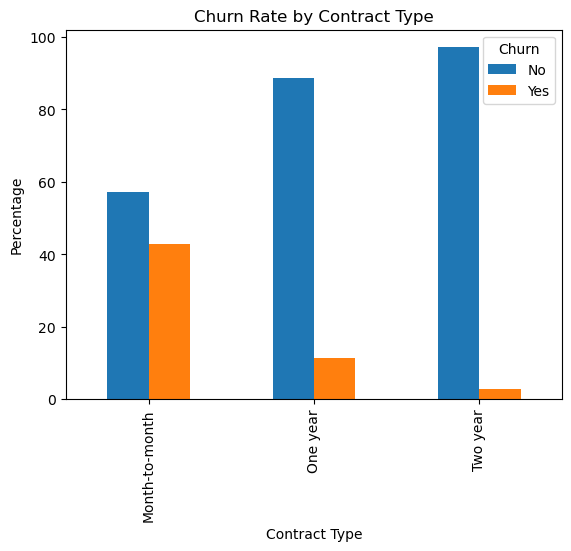

In [14]:
#visualization Contract vs Churn

import pandas as pd

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(kind='bar')

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.show()

### Month-to-month customers exhibit significantly higher churn rates compared to long-term contracts, indicating that lack of commitment is a major driver of customer attrition.

<Figure size 640x480 with 0 Axes>

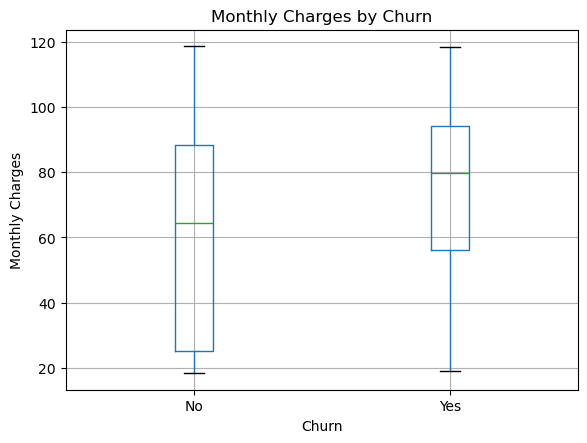

In [16]:
import matplotlib.pyplot as plt

plt.figure()

df.boxplot(column='MonthlyCharges', by='Churn')

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Customers who churned have noticeably higher monthly charges compared to retained customers, suggesting that pricing plays a significant role in customer attrition. This may indicate that customers perceive high-cost plans as offering insufficient value.

### High-paying, short-term customers are the most vulnerable to churn.

In [18]:
df.groupby('Contract')['MonthlyCharges'].mean()

Contract
Month-to-month    66.398490
One year          65.079416
Two year          60.872374
Name: MonthlyCharges, dtype: float64

In [22]:
#Month-to-month customers are paying more than long-term customers

#1. Contract type (biggest driver)
#Month-to-month → ~43% churn (VERY HIGH)
#2. Pricing
#Churned customers pay more (~74 vs ~61)
#3. Contract pricing pattern
#Month-to-month customers ALSO pay more (66.4 highest)

#Customers on month-to-month contracts are not only more likely to churn, but they are also paying higher monthly charges compared to long-term customers.

#This is a risk compounding effect:
#No long-term commitment 
#Higher price burden 
#Higher churn probability 

#These customers are the highest-value loss risk segment

### The analysis reveals a compounding churn risk among month-to-month customers, who not only exhibit the highest churn rate (~43%) but also pay higher average monthly charges compared to long-term contract customers. This suggests that pricing combined with lack of contractual commitment significantly increases churn likelihood.


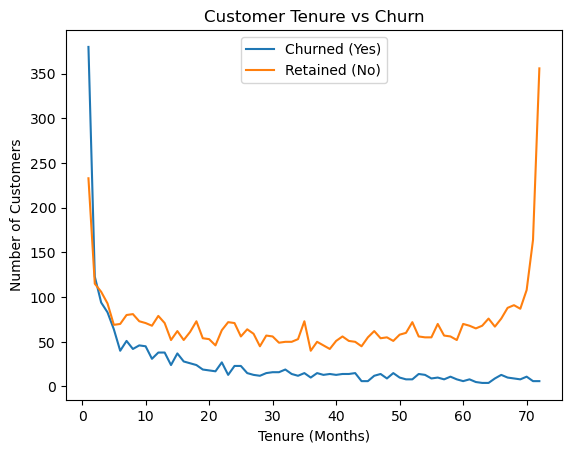

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

tenure_churn = pd.crosstab(df['tenure'], df['Churn'])

plt.figure()

plt.plot(tenure_churn.index, tenure_churn['Yes'], label='Churned (Yes)')
plt.plot(tenure_churn.index, tenure_churn['No'], label='Retained (No)')

plt.title("Customer Tenure vs Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

### Customers are most likely to churn early in their lifecycle, especially within the first year. As tenure increases, customers become significantly more stable.

### The analysis shows that churn is heavily concentrated among new customers, with the highest churn occurring within the first 12 months. After the first year, churn rates decrease significantly, indicating that customer retention improves as tenure increases.

# Churn is driven by early-stage customers on short-term contracts with higher monthly charges.